# 04 · SHAP Explainability Analysis
### Explain the best model with SHapley Additive exPlanations

**Author:** Ibrahim Denis Fofanah — Pace University | RiseAfrica Foundation for STEM and Innovation
**Project:** Machine Learning Approaches to Crop Yield Prediction and Post-Harvest Loss Reduction — Evidence from Sierra Leone

---

In [1]:
# ── Setup & project-root anchoring ────────────────────────────────────────────
import sys, os, warnings

# Resolve paths whether launched from repo root or from notebooks/
if not os.path.exists('data/raw') and os.path.exists('../data/raw'):
    os.chdir('..')
sys.path.insert(0, os.path.abspath('.'))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

warnings.filterwarnings('ignore')
pd.set_option('display.float_format', '{:.2f}'.format)
pd.set_option('display.max_columns', 50)

for d in ['data/processed', 'outputs/figures', 'outputs/models', 'outputs/reports']:
    os.makedirs(d, exist_ok=True)

print(f'Working directory: {os.getcwd()}')

Working directory: /Users/ibrahimfofanah/sierraleone-agri-ml


## 1. Load Data, Features & Best Model

In [2]:
import shap
from src import feature_engineering as fe
from src import models as mdl

ml_df = pd.read_csv('data/processed/processed_dataset.csv')
X, y, feature_names = fe.prepare_features(ml_df, target_col='Rice_Yield')

results_df = pd.read_csv('outputs/reports/model_performance.csv')
best_name = results_df.iloc[0]['Model']
best_model = mdl.load_model(f"outputs/models/{best_name.replace(' ', '_')}.pkl")
print(f'Best model: {best_name}')

[✓] Features: 151 | Samples: 25
    Target: Rice_Yield | Range: 785.6 – 2109.8
[✓] Model loaded: outputs/models/XGBoost.pkl
Best model: XGBoost


## 2. Compute SHAP Values

In [3]:
explainer = shap.TreeExplainer(best_model)
shap_values = explainer.shap_values(X)
print(f'SHAP values shape: {shap_values.shape}')

SHAP values shape: (25, 151)


## 3. SHAP Summary Plot

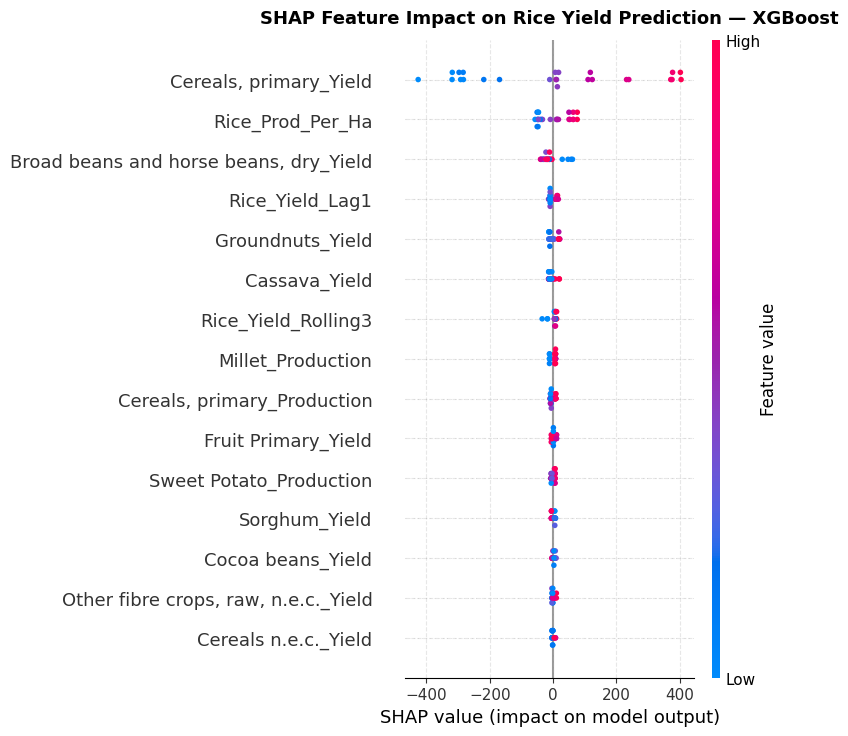

[saved] outputs/figures/fig_shap_summary.png / .pdf


In [4]:
fig = plt.figure(figsize=(10, 8))
shap.summary_plot(shap_values, X, feature_names=feature_names,
                  max_display=15, show=False)
plt.title(f'SHAP Feature Impact on Rice Yield Prediction — {best_name}',
          fontsize=13, fontweight='bold', pad=12)
plt.tight_layout()
plt.savefig('outputs/figures/fig_shap_summary.png', dpi=300, bbox_inches='tight')
plt.savefig('outputs/figures/fig_shap_summary.pdf', bbox_inches='tight')
plt.show()
print('[saved] outputs/figures/fig_shap_summary.png / .pdf')